# Customer Value Segmentation & Business Intelligence Dashboard

## 📊 Project Overview

Customer segmentation is a key business strategy used to understand customer purchasing behaviour and improve marketing effectiveness. This project applies **RFM (Recency, Frequency, Monetary) Analysis** to segment customers based on transaction history.

The analysis identifies valuable customer groups, purchasing patterns, and business opportunities that can help improve customer retention, increase revenue, and support data-driven decision making.

---

## 📑 Table of Contents

1. Import Required Libraries
2. Load Dataset
3. Data Integration
4. Customer Segmentation using RFM Analysis
5. Data Analysis & Visualization
6. RFM Scatter Plots
7. Customer Segment Distribution
8. Executive Summary
9. Business Recommendations
10. Conclusion

---

## 🎯 Business Problem


Businesses often struggle to identify:

- High-value customers
- Customers at risk of leaving
- Loyal and repeat customers
- Customers requiring targeted marketing campaigns

Using RFM analysis, customers can be grouped into meaningful segments for personalized business strategies.

---

## 🎯 Project Objectives


- Clean and prepare customer datasets
- Perform Exploratory Data Analysis (EDA)
- Calculate RFM metrics
- Segment customers based on RFM scores
- Generate business insights
- Build an interactive Tableau dashboard
- Recommend business strategies based on customer behaviour

---

## 🛠 Tech Stack


- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Tableau
- Jupyter Notebook

## 1. Import Required Libraries

This section imports all the Python libraries required for data manipulation, visualization, date processing, and customer segmentation analysis.

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from datetime import datetime, date

# Display plots inside notebook
%matplotlib inline

# Professional plotting theme
sns.set_theme(style="whitegrid", palette="Set2")

# Default figure size
plt.rcParams["figure.figsize"] = (10, 6)

## 📂 Load Dataset

The cleaned transaction and customer demographic datasets are loaded into Pandas DataFrames for further analysis.

In [174]:
trans = pd.read_csv('Transactions_Cleaned.csv')
cust = pd.read_csv('CustomerDemographic_Cleaned.csv')

In [175]:
# Fetching first 5 transaction records

trans.head(5)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,Profit
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0,17.87
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0,1702.55
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0,1544.61
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0,817.36
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0,1055.82


In [176]:
print("Total records (rows) in the Transaction Dataset : {}".format(trans.shape[0]))
print("Total features (columns) in the Transaction Dataset : {}".format(trans.shape[1]))

Total records (rows) in the Transaction Dataset : 19803
Total features (columns) in the Transaction Dataset : 14


In [177]:
# Fetching first 5 Customer Demographics records

cust.head(5)

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,Age
0,1,Laraine,Medendorp,Female,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,Yes,11.0,67
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,Yes,16.0,40
2,3,Arlin,Dearle,Male,61,1954-01-20,Recruiting Manager,Property,Mass Customer,N,Yes,15.0,67
3,4,Talbot,NaN,Male,33,1961-10-03,Missing,IT,Mass Customer,N,No,7.0,59
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13,Senior Editor,Missing,Affluent Customer,N,Yes,8.0,44


In [178]:
print("Total records (rows) in the Customer Demographics Dataset : {}".format(cust.shape[0]))
print("Total features (columns) in the Customer Demographics Dataset : {}".format(cust.shape[1]))

Total records (rows) in the Customer Demographics Dataset : 3912
Total features (columns) in the Customer Demographics Dataset : 13


## 🔄 Data Integration


The transaction dataset is merged with the customer demographic dataset using the **customer_id** field to create a unified dataset for customer behavior analysis.

In [179]:
# Merging both the Transaction Dataset and Customer Demographics Dataset based on customer_id.

merged_trans_cust = pd.merge(trans, cust, left_on='customer_id', right_on='customer_id', how='inner')

In [180]:
# Fetching the first 5 records of the merged dataset.

merged_trans_cust.head(5)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,...,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,Age
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,...,Male,19,1955-01-11,Software Engineer I,Financial Services,Mass Customer,N,Yes,10.0,66
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,...,Female,89,1979-02-04,Clinical Specialist,Health,Mass Customer,N,Yes,10.0,42
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,...,Male,9,1977-06-03,Desktop Support Technician,Retail,Affluent Customer,N,No,22.0,43
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,...,Male,83,1962-01-14,Staff Scientist,Financial Services,Mass Customer,N,No,16.0,59
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,...,Female,29,1996-12-15,Missing,Retail,Affluent Customer,N,Yes,2.0,24


In [181]:
print("Total records (rows) in the Merged Dataset : {}".format(merged_trans_cust.shape[0]))
print("Total features (columns) in the Merged Dataset : {}".format(merged_trans_cust.shape[1]))

Total records (rows) in the Merged Dataset : 19354
Total features (columns) in the Merged Dataset : 26


In [182]:
merged_trans_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 19354 entries, 0 to 19353
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   transaction_id                       19354 non-null  int64  
 1   product_id                           19354 non-null  int64  
 2   customer_id                          19354 non-null  int64  
 3   transaction_date                     19354 non-null  str    
 4   online_order                         19354 non-null  float64
 5   order_status                         19354 non-null  str    
 6   brand                                19354 non-null  str    
 7   product_line                         19354 non-null  str    
 8   product_class                        19354 non-null  str    
 9   product_size                         19354 non-null  str    
 10  list_price                           19354 non-null  float64
 11  standard_cost                        19

<b>The data-type of transaction_date column is not in date-time format. Hence the data-type of the column should be changed from object to datetime type.</b>

In [183]:
merged_trans_cust['transaction_date']= pd.to_datetime(merged_trans_cust['transaction_date'])

# 📈 Customer Segmentation using RFM Analysis

## What is RFM Analysis?

RFM (Recency, Frequency, Monetary) Analysis is a customer segmentation technique widely used in marketing and business analytics.

It evaluates customer behaviour using three key metrics:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often the customer makes purchases.
- **Monetary (M):** Total revenue generated by the customer.

## Business Value

RFM analysis helps organizations:

- Identify loyal and high-value customers
- Detect customers who are at risk of churn
- Design personalized marketing campaigns
- Improve customer retention
- Increase overall business profitability

In [184]:
# Maximum Transaction Date or the latest transaction date.

max_trans_date = max(merged_trans_cust['transaction_date']).date()
max_trans_date

datetime.date(2017, 12, 30)

In [185]:
# Taking the last transaction date as a reference date for comparision and 
# finding the number of days between a transaction date and last transaction date to compute the recency.

comparison_date = datetime.strptime(str(max_trans_date), "%Y-%m-%d")

In [186]:
# Creating a RFM table that will contain all the values for recency , frequency and Monetray data. 

rfm_table = merged_trans_cust.groupby(['customer_id']).agg({'transaction_date': lambda date : (comparison_date - date.max()).days,
                                                            'product_id' : lambda prod_id : len(prod_id), 
                                                            'Profit' : lambda p : sum(p)})

In [187]:
# The columns in rfm_table dataframe are not properly named. Renaming of the columns to appropiate name is needed

rfm_table.columns

Index(['transaction_date', 'product_id', 'Profit'], dtype='str')

In [188]:
# Renaming column names to appropiate names

rfm_table.rename(columns={'transaction_date' : 'recency', 
                        'product_id' : 'frequency',
                        'Profit' : 'monetary'} , inplace=True)

In [189]:
# Dividing the recency, frequency and monetary into 4 quartiles (min, 25%, 50%, 75% and max).
# These values will help us to calculate RFM score for a customer and classify based on their RFM score.

rfm_table['r_quartile'] = pd.qcut(rfm_table['recency'], 4, ['4','3','2','1'])
rfm_table['f_quartile'] = pd.qcut(rfm_table['frequency'], 4, ['1','2','3','4'])
rfm_table['m_quartile'] = pd.qcut(rfm_table['monetary'], 4, ['1','2','3','4'])

In [190]:
# RFM_table dataset

rfm_table

,recency,frequency,monetary,r_quartile,f_quartile,m_quartile
customer_id,,,,,,
1,7,11,3018.09,4,4,3
2,128,3,2226.26,1,1,2
3,102,8,3362.81,1,4,3
4,195,2,220.57,1,1,1
5,16,6,2394.94,4,2,2
...,...,...,...,...,...,...
3496,256,4,2045.84,1,1,2
3497,52,3,1648.32,2,1,1
3498,127,6,3147.33,1,2,3


In [191]:
# Caluclation of RFM Score.
# Max weightage is given to recency then frequency and then  monetary.

rfm_table['rfm_score'] = 100*rfm_table['r_quartile'].astype(int)+10*rfm_table['f_quartile'].astype(int)+rfm_table['m_quartile'].astype(int)

In [192]:
# Assigning a title to a cuustomer.
# Platinum corresponds to highest range of RFM score down to Bronze to lowest range of RFM score.

rfm_table['customer_title'] = pd.qcut(rfm_table['rfm_score'], 4, ['Bronze','Silver','Gold','Platinum'])

In [193]:
# RFM table dataset

rfm_table

,recency,frequency,monetary,r_quartile,f_quartile,m_quartile,rfm_score,customer_title
customer_id,,,,,,,,
1,7,11,3018.09,4,4,3,443,Platinum
2,128,3,2226.26,1,1,2,112,Bronze
3,102,8,3362.81,1,4,3,143,Bronze
4,195,2,220.57,1,1,1,111,Bronze
5,16,6,2394.94,4,2,2,422,Platinum
...,...,...,...,...,...,...,...,...
3496,256,4,2045.84,1,1,2,112,Bronze
3497,52,3,1648.32,2,1,1,211,Bronze
3498,127,6,3147.33,1,2,3,123,Bronze


### Merging both RFM Table with Transaction and Customer Tables

The RFM_Table dataframe is merged with the Transactions and Customer Demographics datasets, to gain depper insights of Customer Segemnts along with transactions. The dataframes are joined based on customer_ids from both the datasets

In [194]:
cust_trans_rfm = pd.merge(merged_trans_cust, rfm_table, left_on='customer_id', right_on='customer_id', how='inner')

In [195]:
cust_trans_rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 19354 entries, 0 to 19353
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   transaction_id                       19354 non-null  int64         
 1   product_id                           19354 non-null  int64         
 2   customer_id                          19354 non-null  int64         
 3   transaction_date                     19354 non-null  datetime64[us]
 4   online_order                         19354 non-null  float64       
 5   order_status                         19354 non-null  str           
 6   brand                                19354 non-null  str           
 7   product_line                         19354 non-null  str           
 8   product_class                        19354 non-null  str           
 9   product_size                         19354 non-null  str           
 10  list_price           

<b> The datatypes of the columns looks fine.</b>

### Creating an Age Group Feature

In [196]:
cust_trans_rfm['Age_Group'] = cust_trans_rfm['Age'].apply(lambda x : (math.floor(x/10)+1)*10)

### Creating a Detail Customer title / tag based on RFM Score

An extended version of customer title is made which divides the entire number of customers into 11 groups. The groups are mainly Platinum Customers, Very Loyal, Becoming Loyal, Recent Customers, Potential Customers, Late Bloomer, Loosing Customers, High Risk Customers, Almost Lost Customers, Evasive Customers and Lost Customers.<br>
The demarkation of customers into the above mentioned groups is based on their RFM scores.

In [197]:
# Function as a lookup to appropiate customer titles based on RFM score.

def cust_score_title_lkup(cols):
    
    rfm_score = cols["rfm_score"]
    
    if rfm_score >= 444:
        return 'Platinum Customer'
    elif rfm_score >=433 and rfm_score < 444:
        return 'Very Loyal'
    elif rfm_score >=421 and rfm_score < 433:
        return 'Becoming Loyal'
    elif rfm_score >=344 and rfm_score < 421:
        return 'Recent Customer'
    elif rfm_score >=323 and rfm_score < 344:
        return 'Potential Customer'
    elif rfm_score >=311 and rfm_score < 323:
        return 'Late Bloomer'
    elif rfm_score >=224 and rfm_score < 311:
        return 'Loosing Customer'
    elif rfm_score >=212 and rfm_score < 224:
        return 'High Risk Customer'
    elif rfm_score >=124 and rfm_score < 212:
        return 'Almost Lost Customer'
    elif rfm_score >=112 and rfm_score < 124:
        return 'Evasive Customer'
    else :
        return 'Lost Customer'

In [198]:
# Applying the above functions and creating a new feature detail_cust_title

cust_trans_rfm['detail_cust_title']=cust_trans_rfm[['rfm_score']].apply(cust_score_title_lkup, axis=1)

In [199]:
def get_rank(cols):

    title = cols["detail_cust_title"]

    if title == 'Platinum Customer':
        return 1
    elif title == 'Very Loyal':
        return 2
    elif title == 'Becoming Loyal':
        return 3
    elif title == 'Recent Customer':
        return 4
    elif title == 'Potential Customer':
        return 5
    elif title == 'Late Bloomer':
        return 6
    elif title == 'Loosing Customer':
        return 7
    elif title == 'High Risk Customer':
        return 8
    elif title == 'Almost Lost Customer':
        return 9
    elif title == 'Evasive Customer':
        return 10
    else:
        return 11

In [200]:
cust_trans_rfm["rank"] = cust_trans_rfm[["detail_cust_title"]].apply(
    get_rank,
    axis=1
)

In [201]:
# Applying the above functions and creating a new feature rank

cust_trans_rfm['rank']=cust_trans_rfm[['detail_cust_title']].apply(get_rank, axis=1)

## 2.📤 Export Dataset


After performing data quality assessment(DQA), data cleaning and RFM Analysis on the dataset, it's time to export the dataset to a csv file for further <b>exploratory data analysis (EDA)</b> and this data will drive the <b>Sales Customer Segmenation Dashboard</b> developed in <b>Tableau</b>.

In [202]:
cust_trans_rfm.to_csv('Customer_Trans_RFM_Analysis.csv', index=False)

In [203]:
print("Total records in final dataset : {}".format(cust_trans_rfm.shape[0]))

Total records in final dataset : 19354


## 3.  📊 Data Analysis and Exploration

### 3.1. New Customer vs Old Customer Age Distributions

Most New / Old Customers are aged between 40-49. The lowest age groups are under 20 and 80+ for both Old and New Customers dataset.<br>
Among the New Customers the most populated age bracket is 20-29 and 60-69, while the maximum Old Customers are from the age bracket 50-69.<br>
There is a steep drop in number of customers in 30-39 age groupsd among the New Customers.<br>

In [204]:
# Loading the New Customers Dataset

new_cust = pd.read_csv('NewCustomerList_Cleaned.csv')

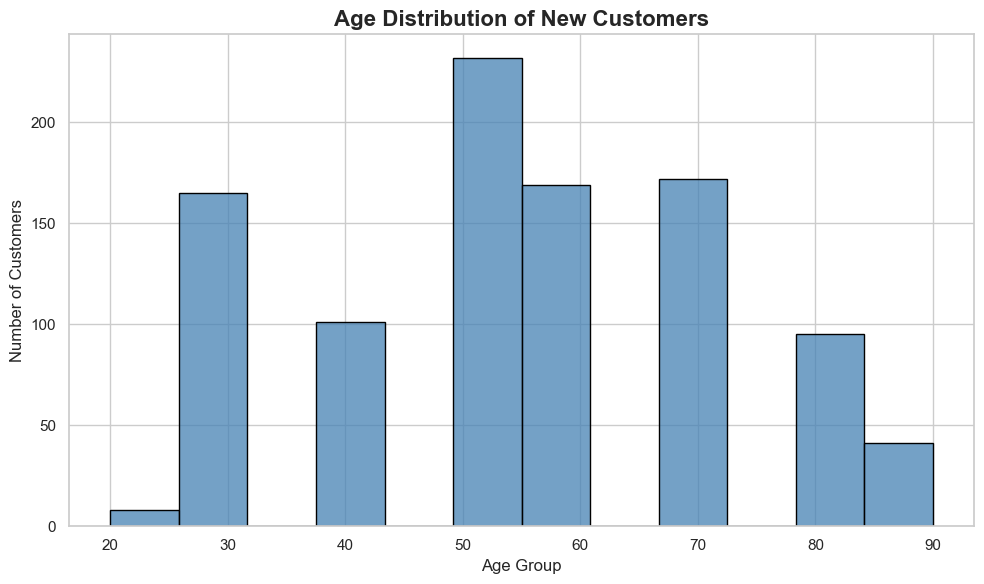

In [205]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=new_cust,
    x="Age Group",
    bins=12,
    color="steelblue",
    edgecolor="black"
)

plt.title("Age Distribution of New Customers", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

<b>Here 20 = under 20, 30 = 20-29 age bracket</b>

### 📌 Business Insight

- The majority of new customers belong to the middle-age group.
- Younger and older age groups contribute comparatively fewer customers.
- Marketing campaigns should primarily target the dominant age segment while designing specialized campaigns for underrepresented groups to improve customer acquisition.

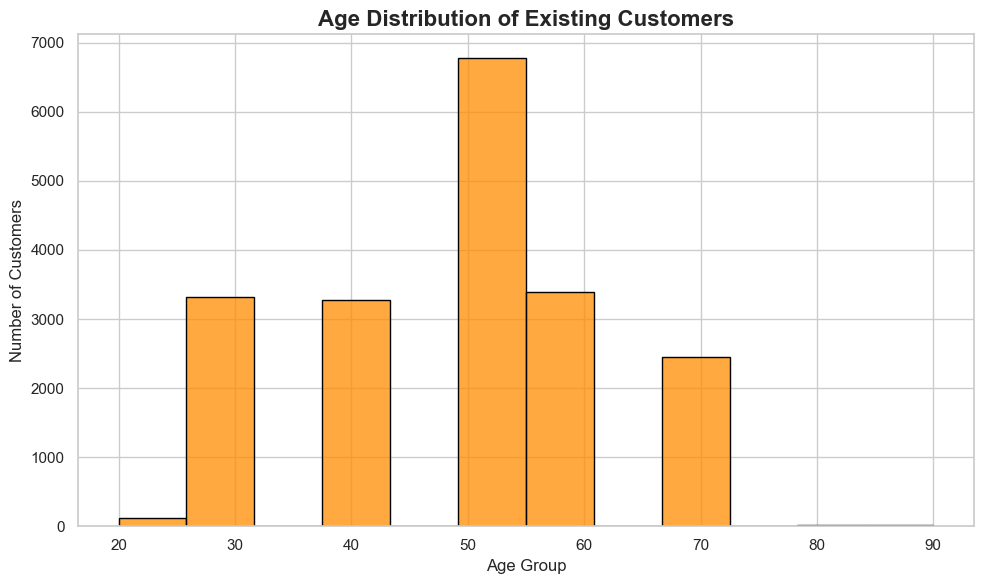

In [206]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=cust_trans_rfm,
    x="Age_Group",
    bins=12,
    color="darkorange",
    edgecolor="black"
)

plt.title("Age Distribution of Existing Customers", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

<b>Here 20 = under 20, 30 = 20-29 age bracket</b>

### 📌 Business Insight

- Existing customers are concentrated within a limited age range, indicating a stable customer base.
- The company has strong retention among its primary customer segment.
- Expanding marketing efforts towards younger customers could help diversify the customer portfolio and improve long-term growth.

### 3.2. Bike related purchases over last 3 years by gender

Over the last 3 years approximately 51% of the buyers are women and 49% were male buyers.<br>
Female purchases are approximately 10,000 more than male (numerically). Gender wise majority of the bike sales comes from female customers.<br>

In [207]:
cust_bike_purchase_by_gender = cust_trans_rfm.groupby('gender').agg({'past_3_years_bike_related_purchases' : sum}
                                                                 ).reset_index()

In [208]:
total_records = cust_trans_rfm['past_3_years_bike_related_purchases'].sum()

In [209]:
cust_bike_purchase_by_gender['Percent_of_total'] = (cust_bike_purchase_by_gender['past_3_years_bike_related_purchases']
                                                        /total_records)*100

In [210]:
cust_bike_purchase_by_gender

,gender,past_3_years_bike_related_purchases,Percent_of_total
0,Female,478488,50.503731
1,Male,468943,49.496269


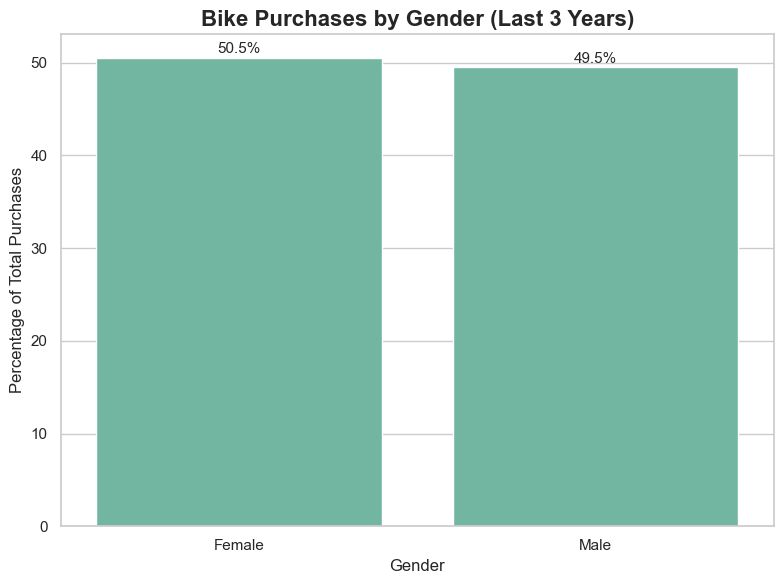

In [211]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=cust_bike_purchase_by_gender,
    x="gender",
    y="Percent_of_total"
)

plt.title("Bike Purchases by Gender (Last 3 Years)", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Percentage of Total Purchases")

# Add percentage labels
for index, value in enumerate(cust_bike_purchase_by_gender["Percent_of_total"]):
    plt.text(index, value + 0.5, f"{value:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### 📌 Business Insight

- Female customers account for a slightly higher percentage of bike purchases than male customers.
- This indicates that female customers represent an important customer segment for the business.
- Marketing campaigns and promotional offers can be tailored to strengthen engagement with both customer groups while maintaining the strong female customer base.

### 3.3 Job Industry Customer Distribution

Among the <b>New Customers</b> the highest amount of sales comes from customers having a job in Manufacturing and Financial services sector. The samllest chunk of sales comes from customers in Agriculture sector and from Telecom sector with 3% sales only. Similar trend is observed among <b>Old Customers</b>.

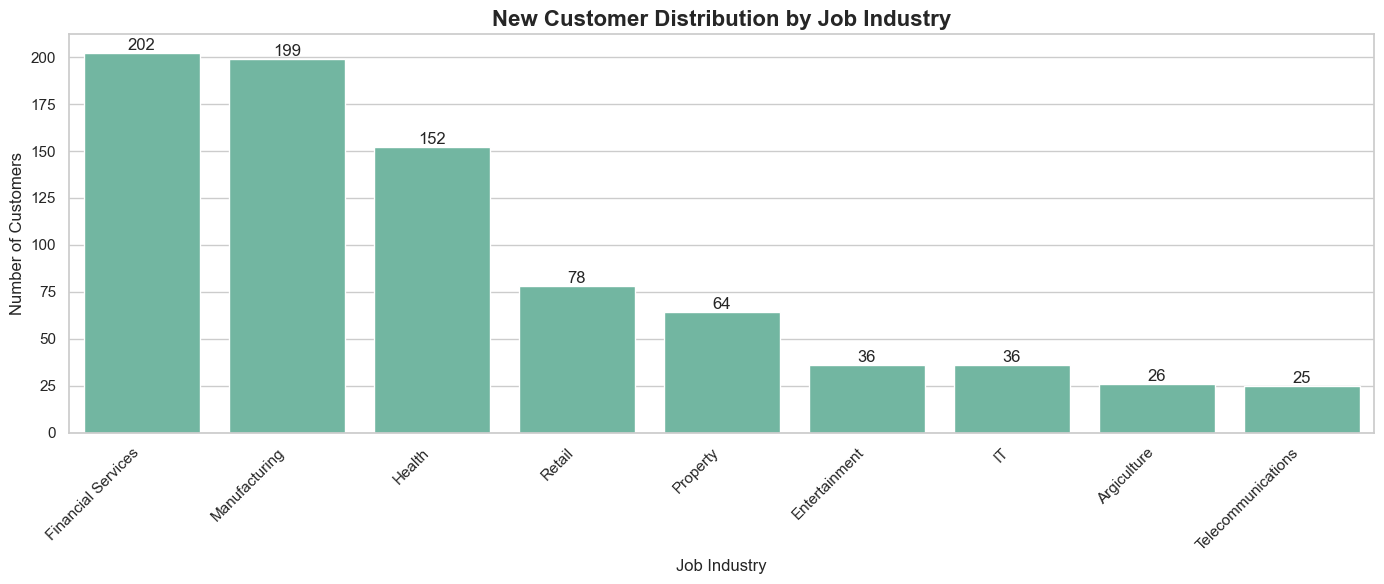

In [212]:
plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=new_cust[new_cust["job_industry_category"] != "Missing"],
    x="job_industry_category",
    order=new_cust[new_cust["job_industry_category"] != "Missing"]["job_industry_category"].value_counts().index
)

plt.title("New Customer Distribution by Job Industry", fontsize=16, fontweight="bold")
plt.xlabel("Job Industry")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 📌 Business Insight

- Manufacturing and Financial Services contribute the largest share of new customers.
- Industries with fewer customers represent potential growth opportunities.
- Industry-specific marketing campaigns can improve customer acquisition and engagement.

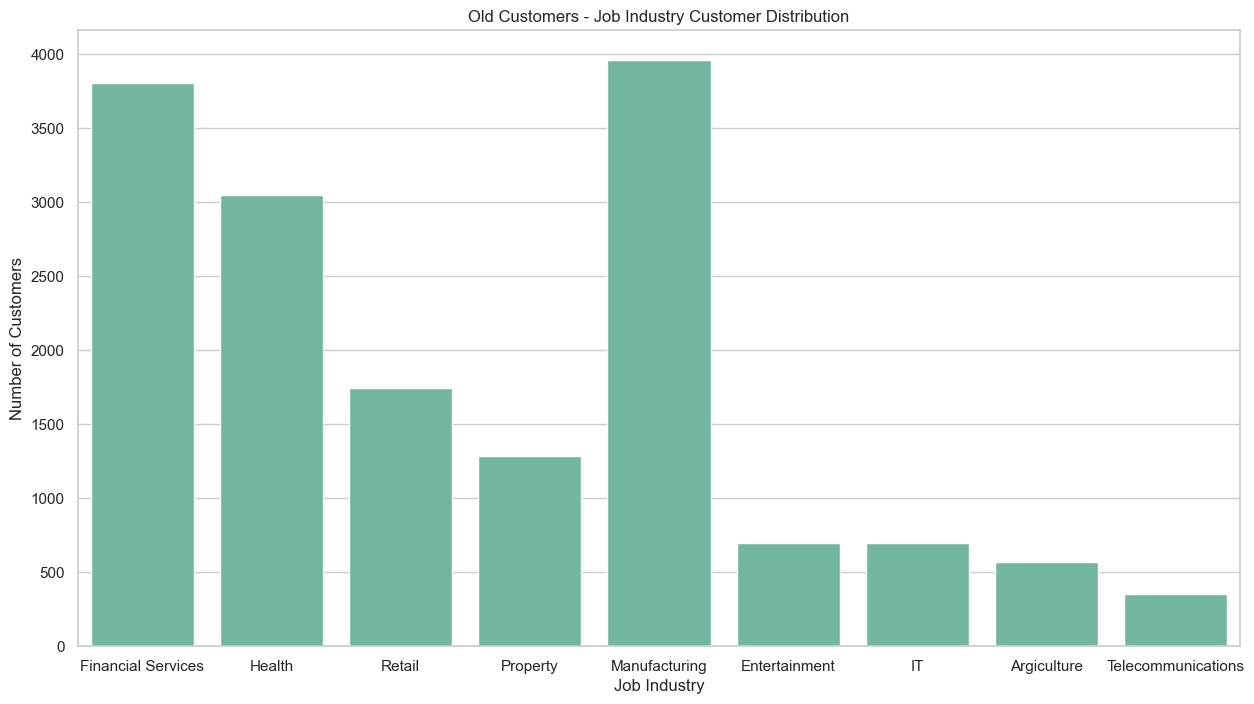

In [213]:
plt.figure(figsize=(15,8))
sns.countplot(x='job_industry_category',data=cust_trans_rfm[~(cust_trans_rfm['job_industry_category']=='Missing')])
plt.xlabel('Job Industry')
plt.ylabel('Number of Customers')
plt.title('Old Customers - Job Industry Customer Distribution')

plt.show()

### 📌 Business Insight

- Existing customers are also concentrated in the Manufacturing and Financial Services sectors.
- The similar distribution between new and existing customers indicates a stable customer base across these industries.
- Businesses can prioritize these sectors while exploring strategies to expand into underrepresented industries.

### 3.4. Wealth Segmentation by Age Group

Across all Age Groups the maximum number of customers are classified as 'Mass Customers'. The next being 'High Net Worth'. However among 40-49 aged customers 'Affluent Customers' outperforms the 'High Net Worth' customers.

<b>New Customers</b>

In [214]:
wealth_age_seg_new = new_cust.groupby(['wealth_segment', 'Age Group']).size().reset_index()

In [215]:
wealth_age_seg_new.rename(columns={0:'Number of Customers'}, inplace=True)
wealth_age_seg_new

,wealth_segment,Age Group,Number of Customers
0,Affluent Customer,20,3
1,Affluent Customer,30,49
2,Affluent Customer,40,15
3,Affluent Customer,50,58
4,Affluent Customer,60,40
5,Affluent Customer,70,41
6,Affluent Customer,80,20
7,Affluent Customer,90,9
8,High Net Worth,30,42
9,High Net Worth,40,34


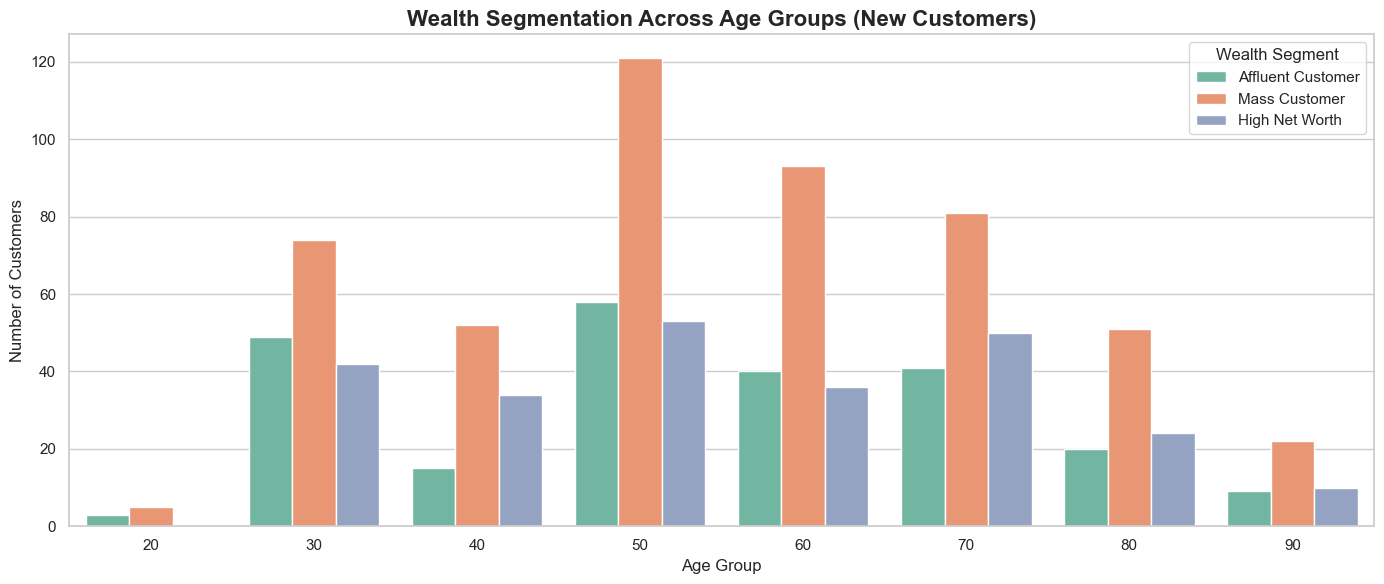

In [216]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=wealth_age_seg_new,
    x="Age Group",
    y="Number of Customers",
    hue="wealth_segment"
)

plt.title("Wealth Segmentation Across Age Groups (New Customers)", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.legend(title="Wealth Segment")
plt.tight_layout()
plt.show()

In all the age groups the most number of customers are 'Mass Customers'. The 2nd largest customer base being the 'High Net Worth' group.<br>In the age group 40-49 the 'Affluent Customer' group outperforms 'High Net Worth' group

### 📌 Business Insight

- Mass Market customers form the largest customer group across almost every age category.
- High Net Worth customers represent the second-largest segment.
- Premium marketing campaigns can be designed specifically for Affluent and High Net Worth customers to increase revenue.

<b>Old Customers</b>

Similar treand (like that of New Customers) is observed among Old Customers

In [217]:
wealth_age_seg_old = cust_trans_rfm.groupby(['wealth_segment', 'Age_Group']).size().reset_index()

In [218]:
wealth_age_seg_old.rename(columns={0:'Number of Customers'}, inplace=True)

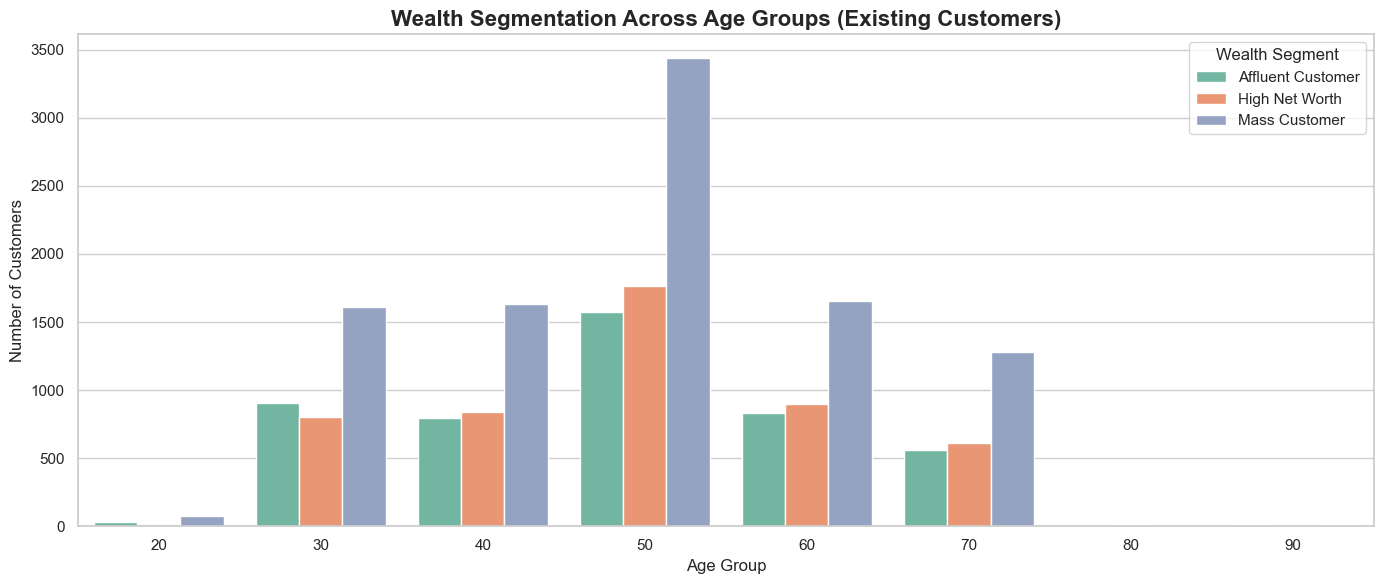

In [219]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=wealth_age_seg_old,
    x="Age_Group",
    y="Number of Customers",
    hue="wealth_segment"
)

plt.title("Wealth Segmentation Across Age Groups (Existing Customers)", fontsize=16, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.legend(title="Wealth Segment")
plt.tight_layout()
plt.show()

### 📌 Business Insight

- Existing customers show a similar wealth distribution, with Mass Market customers dominating across age groups.
- High Net Worth and Affluent customers contribute a valuable customer segment.
- Personalized offers for premium customers can improve customer lifetime value and loyalty.

### 3.5. Car owner across each State

The customer base of the automobile bike company lies in New South Wales, Queensland and Victoria, Australia. <br>
In New South Wales (NSW) it seems there is a greater amount of people who donot own a car. In Victoria (VIC) the proportion is evenly split. However in Queensland (QLD) there are relatively more people who own the car.

In [220]:
# Loading the Customer Address Dataset.

cust_addr_info = pd.read_csv('CustomerAddress_Cleaned.csv')

In [221]:
# Merging the RFM data with Customer Address dataset.

cust_trans_addr = pd.merge(cust_trans_rfm , cust_addr_info, left_on = 'customer_id' , 
                           right_on = 'customer_id', how='inner')

In [222]:
print("RFM table Records count : {}\nAddress Table Records count :{}".format(cust_trans_rfm.shape[0] ,cust_addr_info.shape[0]))

RFM table Records count : 19354
Address Table Records count :3999


In [223]:
state_car_owners = cust_trans_addr[['state' , 'owns_car' , 'customer_id']].drop_duplicates().groupby(['state', 'owns_car']).size().reset_index()

In [224]:
state_car_owners.rename(columns={0:'Number of Customers'}, inplace=True)
state_car_owners

,state,owns_car,Number of Customers
0,NSW,No,889
1,NSW,Yes,935
2,QLD,No,365
3,QLD,Yes,363
4,VIC,No,435
5,VIC,Yes,425


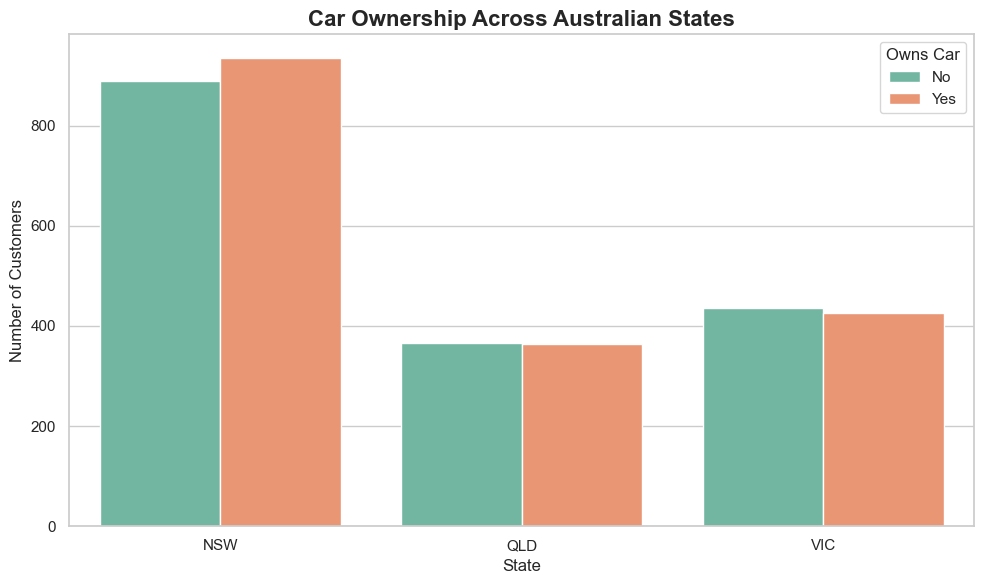

In [225]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=state_car_owners,
    x="state",
    y="Number of Customers",
    hue="owns_car"
)

plt.title("Car Ownership Across Australian States", fontsize=16, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.legend(title="Owns Car")

plt.tight_layout()
plt.show()

NSW has the largest number of people that donot own a car. It seems that a higher amount of data is collected from NSW compared to other states. In QLD the distribution between customers having a car or not having is even. In Victoria the number is split evenly. Both the numbers are significantly lower than that of NSW

### 📌 Business Insight


- New South Wales (NSW) has the highest customer concentration among all states.
- Car ownership patterns vary across regions, indicating differences in customer demographics and lifestyle.
- Regional marketing strategies can be tailored based on vehicle ownership trends to improve campaign effectiveness.

## 4.  📉 RFM Analysis Scatter Plots

### 4.1. Recency vs Monetary

The chart shows that customers who purchased recently generated more revenue than customers who visited long time ago. Customers from recent past (50-100) days generated a moderate revenue. Customers who visited 200 days ago generated a low revenue.

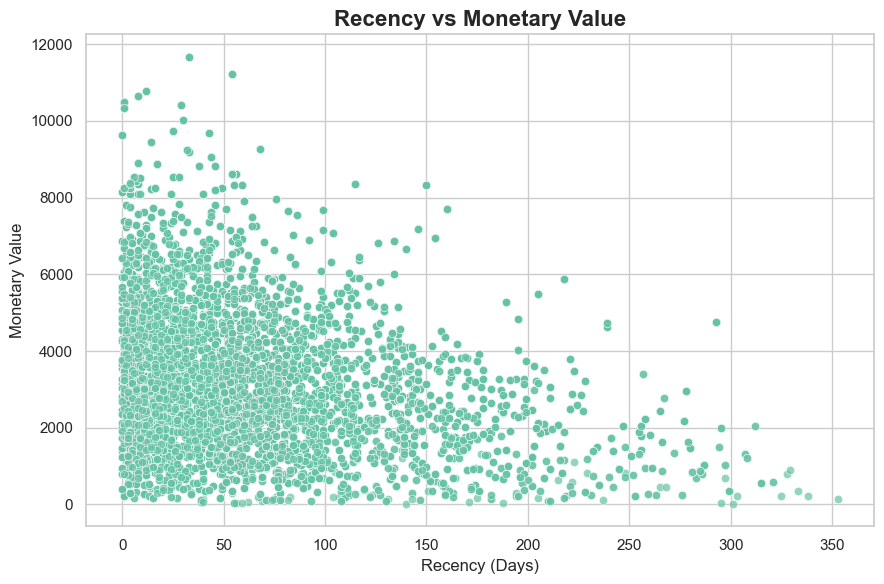

In [226]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=cust_trans_rfm,
    x="recency",
    y="monetary",
    alpha=0.7
)

plt.title("Recency vs Monetary Value", fontsize=16, fontweight="bold")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

### 📌 Business Insight

- Customers who made recent purchases generally generated higher revenue.
- Customers with longer periods of inactivity contributed lower monetary value.
- Re-engagement campaigns targeting inactive customers can help improve future sales.

### 4.2 Frequency vs Monetary

Customers classified as "Platinum Custoers" , "Very Loyal" and "Becoming Loyal" visit frequently, which correlated with increased revenue for the business. 

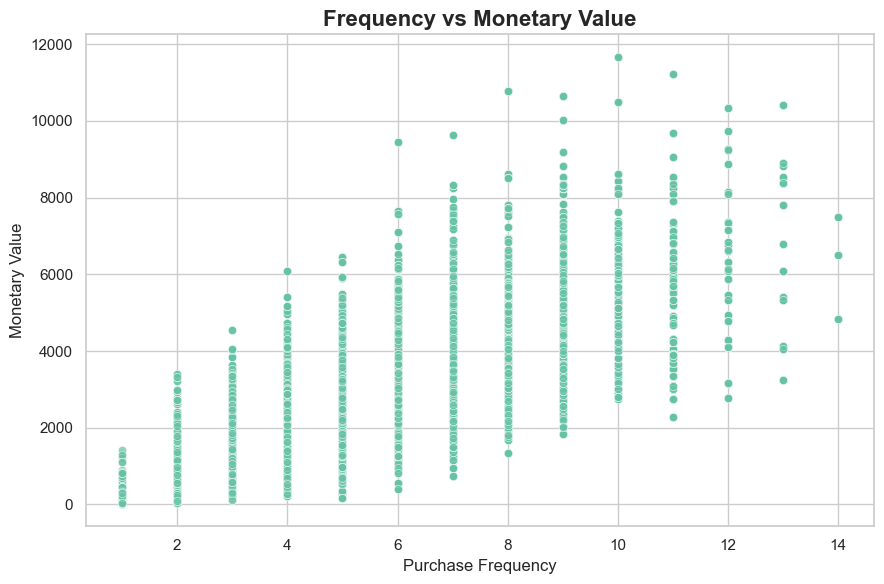

In [227]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=cust_trans_rfm,
    x="frequency",
    y="monetary",
    alpha=0.7
)

plt.title("Frequency vs Monetary Value", fontsize=16, fontweight="bold")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

### 📌 Business Insight

- Customers who purchase more frequently tend to generate higher revenue.
- Frequent buyers represent the most valuable customer segment and contribute significantly to overall business profitability.
- Reward programs, exclusive offers, and personalized recommendations can encourage repeat purchases and improve customer lifetime value.

## 5.  👥 Customer Segment Distribution

<b>Finally we can plot the Number of Customers present under a Customer Segment.</b>

In [228]:
print(cust_trans_rfm.columns)

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'online_order', 'order_status', 'brand', 'product_line',
       'product_class', 'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date', 'Profit', 'first_name', 'last_name',
       'gender', 'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'owns_car', 'tenure', 'Age', 'recency', 'frequency', 'monetary',
       'r_quartile', 'f_quartile', 'm_quartile', 'rfm_score', 'customer_title',
       'Age_Group', 'detail_cust_title', 'rank'],
      dtype='str')


In [229]:
# Calculating the number of unique customers under a customer title.

cust_per_title = cust_trans_rfm[['detail_cust_title', 'customer_id','rank']].drop_duplicates().groupby(
    ['detail_cust_title','rank']).size().reset_index().sort_values('rank')

In [230]:
cust_per_title.rename(columns={0:'Number of Customers'}, inplace=True)
cust_per_title

,detail_cust_title,rank,Number of Customers
7,Platinum Customer,1,164
10,Very Loyal,2,181
1,Becoming Loyal,3,344
9,Recent Customer,4,357
8,Potential Customer,5,340
4,Late Bloomer,6,332
5,Loosing Customer,7,333
3,High Risk Customer,8,371
0,Almost Lost Customer,9,315
2,Evasive Customer,10,388


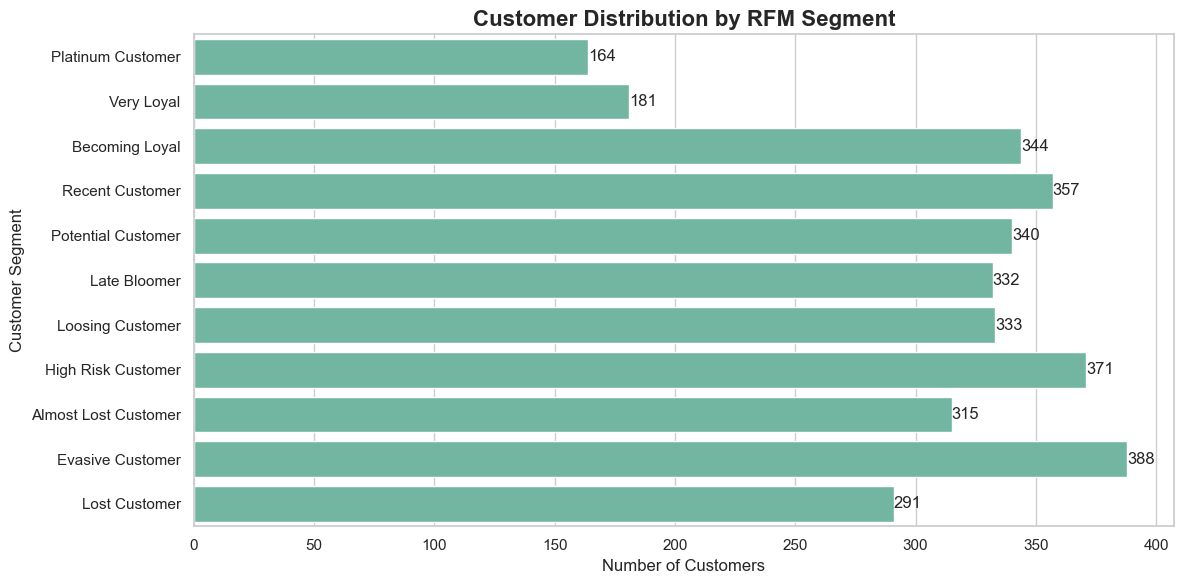

In [231]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=cust_per_title,
    y="detail_cust_title",
    x="Number of Customers"
)

plt.title("Customer Distribution by RFM Segment", fontsize=16, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 📌 Business Insight

- The customer base is distributed across multiple RFM segments, reflecting different purchasing behaviors.
- High-value segments such as **Platinum Customer** and **Very Loyal** contribute significantly to business revenue and should be prioritized for retention.
- Customers in **High Risk**, **Almost Lost**, and **Lost Customer** segments require targeted re-engagement campaigns to reduce churn.

# 📋 Executive Summary

This project applied RFM (Recency, Frequency, Monetary) Analysis to segment customers based on purchasing behavior.

Key findings include:

- Most customers belong to the Mass Market wealth segment.
- Female customers contribute slightly more purchases than male customers.
- Manufacturing and Financial Services represent the largest customer industries.
- Customers with higher purchase frequency generate significantly greater revenue.
- RFM segmentation successfully identified high-value, loyal, and at-risk customer groups.

The analysis provides actionable insights that can support customer retention, targeted marketing, and revenue growth strategies.

# 💼 Business Recommendations

Based on the analysis, the following recommendations are suggested:

1. Reward Platinum and Very Loyal customers with exclusive loyalty programs.
2. Launch personalized campaigns for High Risk and Lost Customers to improve retention.
3. Increase marketing efforts in Manufacturing and Financial Services industries.
4. Design targeted promotions for younger customer segments to expand the customer base.
5. Focus marketing resources on high-value customer segments to maximize return on investment.

# 🏆 Key Results

- Identified 11 customer segments using RFM Analysis.
- Platinum Customers generated the highest business value.
- Female customers contributed slightly more purchases.
- Manufacturing and Financial Services had the largest customer base.
- Tableau dashboard was created for business reporting.

# 🎯 Conclusion

Customer segmentation using RFM Analysis provides valuable business intelligence by identifying customer purchasing patterns and behavior.

The insights generated from this project can help organizations improve customer retention, optimize marketing strategies, and make data-driven business decisions.

By combining Python for data analysis and Tableau for interactive visualization, this project demonstrates an end-to-end analytics workflow suitable for real-world business applications.

# Thank You

Thank you for reviewing this project.

This notebook demonstrates an end-to-end customer segmentation workflow using Python, RFM Analysis, and Tableau to generate actionable business insights.

For feedback or collaboration, feel free to connect with me.